# Regular Season Game Prediction with Wide & Deep Neural Network
This notebook predicts regular season college basketball games using running statistics to avoid data leakage.

## Key Features:
- Running statistics calculated game-by-game (no future data leakage)
- Excludes games where team stats contain zeros
- Home court advantage
- Adjusted offensive/defensive efficiency (AdjO/AdjD)
- Opponent strength adjustment
- Consistency metrics
- Form rating (recent performance)

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy import stats
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import copy
import os
from pathlib import Path
from collections import defaultdict
import sportsdataverse.mbb as mbb

## Load Data

In [2]:
# Load reference team data from SportsDataVerse (ESPN)
try:
    mens_teams_raw = mbb.espn_mbb_teams(return_as_pandas=True)
    id_col = "team_uid" if "team_uid" in mens_teams_raw.columns else "team_id"
    name_col = "team_display_name" if "team_display_name" in mens_teams_raw.columns else "team_name"
    mens_teams = (
        mens_teams_raw[[id_col, name_col]]
        .rename(columns={id_col: "TeamID", name_col: "TeamName"})
        .drop_duplicates()
        .reset_index(drop=True)
    )
    print(f"Teams: {len(mens_teams)}")
    mens_teams.head()
except Exception as exc:
    print(f"Warning: failed to load teams from SportsDataVerse: {exc}")
    mens_teams = pd.DataFrame(columns=["TeamID", "TeamName"])
    mens_teams.head()
mens_teams.to_csv('data/mens_teams.csv', index=False)
mens_teams.head()

Teams: 362


,TeamID,TeamName
0,s:40~l:41~t:2000,Abilene Christian Wildcats
1,s:40~l:41~t:2005,Air Force Falcons
2,s:40~l:41~t:2006,Akron Zips
3,s:40~l:41~t:2010,Alabama A&M Bulldogs
4,s:40~l:41~t:333,Alabama Crimson Tide


In [3]:
from datetime import date
def _filter_by_date(df, start_date, end_date):
    if df is None or len(df) == 0:
        return df
    date_col = next((col for col in df.columns if 'date' in col.lower()), None)
    if date_col is None:
        print('Warning: No date column found. Returning unfiltered data.')
        return df
    filtered = df.copy()
    # Normalize to UTC to avoid tz-naive vs tz-aware comparisons.
    filtered[date_col] = pd.to_datetime(filtered[date_col], errors='coerce', utc=True)
    start_date = pd.to_datetime(start_date, utc=True)
    end_date = pd.to_datetime(end_date, utc=True)
    return filtered[(filtered[date_col] >= start_date) & (filtered[date_col] <= end_date)]

def _load_by_season(loader, seasons):
    frames = []
    for season in seasons:
        try:
            frames.append(loader(seasons=[season], return_as_pandas=True))
        except Exception as exc:
            print(f"Warning: failed to load season {season}: {exc}")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)

def import_recent_matchups(from_date, to_date=None):
    end_date = to_date or pd.Timestamp.today().strftime('%Y-%m-%d')
    start_date = pd.to_datetime(from_date, utc=True)
    end_date = pd.to_datetime(end_date, utc=True)
    seasons = list(range(start_date.year, end_date.year + 1))
    try:
        schedule = _load_by_season(mbb.load_mbb_schedule, seasons)
        player_box = _load_by_season(mbb.load_mbb_player_boxscore, seasons)
        team_box = _load_by_season(mbb.load_mbb_team_boxscore, seasons)
        schedule = _filter_by_date(schedule, start_date, end_date)
        player_box = _filter_by_date(player_box, start_date, end_date)
        team_box = _filter_by_date(team_box, start_date, end_date)
        print(f"Successfully imported range from {start_date.date()} to {end_date.date()}.")
        return schedule, player_box, team_box
    except Exception as exc:
        print(f"Fatal Error: {exc}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

last_date_fetched = '03-02-2026' # Adjust to whatever start date you want for fetching matchups
schedule, player_box, team_box = import_recent_matchups(last_date_fetched, date.today().strftime('%Y-%m-%d'))

team_box_path = 'data/Alltime_Matchups_Team_Box_Score.csv'
player_box_path = 'data/Alltime_Matchups_Box_Score.csv'
if os.path.exists(team_box_path):
    existing_team_box = pd.read_csv(team_box_path)
    combined_team_box = pd.concat([existing_team_box, team_box], ignore_index=True, sort=False)
else:
    combined_team_box = team_box.copy()

combined_team_box = combined_team_box.drop_duplicates().reset_index(drop=True)
combined_team_box.to_csv(team_box_path, index=False)

if os.path.exists(player_box_path):
    existing_player_box = pd.read_csv(player_box_path)
    combined_player_box = pd.concat([existing_player_box, player_box], ignore_index=True, sort=False)
else:
    combined_player_box = player_box.copy()

combined_player_box = combined_player_box.drop_duplicates().reset_index(drop=True)
combined_player_box.to_csv(player_box_path, index=False)

100%|██████████| 1/1 [00:00<00:00,  3.74it/s]


Successfully imported range from 2026-03-02 to 2026-03-04.


C:\Users\sathv\AppData\Local\Temp\ipykernel_40680\2292650694.py:60: DtypeWarning: Columns (0: active, 1: athlete_headshot_href) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_player_box = pd.read_csv(player_box_path)


In [4]:
team_box_usecols = [
    "game_id", "season", "game_date", "season_type",
    "team_name", "team_display_name", "team_abbreviation", "team_slug", "team_uid", "team_location",
    "team_winner", "team_home_away", "team_score",
    "field_goals_made", "field_goals_attempted",
    "three_point_field_goals_made", "three_point_field_goals_attempted",
    "free_throws_made", "free_throws_attempted",
    "offensive_rebounds", "defensive_rebounds", "assists", "turnovers", "steals", "blocks", "fouls",
    "total_rebounds"
]

team_box_score = pd.read_csv(
    "data/Alltime_Matchups_Team_Box_Score.csv",
    engine="pyarrow",
    usecols=team_box_usecols,
)
team_box_score.head()

,game_id,season,game_date,season_type,team_name,team_display_name,team_abbreviation,team_slug,team_uid,team_location,...,free_throws_made,free_throws_attempted,offensive_rebounds,defensive_rebounds,assists,turnovers,steals,blocks,fouls,total_rebounds
0,230682250,2003,2003-03-10 00:00:00+00:00,2,Gaels,Saint Mary's Gaels,SMC,saint-marys-gaels,s:40~l:41~t:2608,Saint Mary's,...,16,23,10,20,7,18,3,3,21,34
1,230682250,2003,2003-03-10 00:00:00+00:00,2,Bulldogs,Gonzaga Bulldogs,GONZ,gonzaga-bulldogs,s:40~l:41~t:2250,Gonzaga,...,21,27,12,23,9,8,10,3,20,41
2,233432507,2004,2003-12-09 00:00:00+00:00,2,Fighting Illini,Illinois Fighting Illini,ILL,illinois-fighting-illini,s:40~l:41~t:356,Illinois,...,3,8,16,20,17,22,6,2,20,38
3,233432507,2004,2003-12-09 00:00:00+00:00,2,Friars,Providence Friars,PROV,providence-friars,s:40~l:41~t:2507,Providence,...,11,19,19,20,14,14,10,7,12,44
4,233300013,2004,2003-11-26 00:00:00+00:00,2,Buffaloes,Colorado Buffaloes,COLO,colorado-buffaloes,s:40~l:41~t:38,Colorado,...,16,23,12,33,9,14,9,6,17,48


## Starters vs Bench Grouped Stats

In [5]:
def build_starter_bench_stats(
    player_box_path: str = "data/Alltime_Matchups_Box_Score.csv",
    seasons=None,
) -> pd.DataFrame:
    """
    Load the player boxscore CSV and return a DataFrame grouped by
    (GameID, Season, TeamID, PlayerGroup) where PlayerGroup is
    'starter' or 'bench'.

    Column naming follows the same convention as the converted matchups
    DataFrame: PascalCase identifiers and short stat abbreviations
    (FGM, FGA, FGM3, FGA3, FTM, FTA, OR, DR, Ast, TO, Stl, Blk, PF).

    Parameters
    ----------
    player_box_path : str
        Path to the persisted player boxscore CSV.
    seasons : list[int] | None
        If provided, filter to only these season values.

    Returns
    -------
    pd.DataFrame
        One row per game × team × PlayerGroup with summed counting
        stats and derived shooting efficiency columns.
    """
    usecols = [
        "game_id", "season", "game_date", "season_type",
        "team_id", "team_uid", "team_display_name", "home_away",
        "team_winner", "team_score", "opponent_team_id", "opponent_team_score",
        "starter", "did_not_play", "active",
        "minutes", "points",
        "field_goals_made", "field_goals_attempted",
        "three_point_field_goals_made", "three_point_field_goals_attempted",
        "free_throws_made", "free_throws_attempted",
        "offensive_rebounds", "defensive_rebounds", "rebounds",
        "assists", "turnovers", "steals", "blocks", "fouls",
    ]

    pb = pd.read_csv(player_box_path, usecols=usecols, engine="pyarrow")

    # Robust playable filter: do not rely on inconsistent `active` values across seasons.
    pb["minutes"] = pd.to_numeric(pb["minutes"], errors="coerce").fillna(0)
    pb = pb[(pb["did_not_play"].fillna(False) == False) & (pb["minutes"] > 0)].copy()

    # Optional season filter
    if seasons is not None:
        pb = pb[pb["season"].isin(seasons)].copy()

    # Label each row as starter or bench
    pb["PlayerGroup"] = pb["starter"].map({True: "starter", False: "bench"})

    # Use team_uid as SDV team id (consistent with the rest of the notebook)
    pb["TeamID"] = pb["team_uid"].fillna(pb["team_id"].astype(str))

    # Remap home_away to H / A / N (same as WLoc in matchups)
    pb["HomeAway"] = pb["home_away"].str.lower().map({
        "home": "H", "away": "A"
    }).fillna("N")

    # Stat columns to aggregate → renamed to match matchups abbreviations
    raw_to_abbr = {
        "minutes":                              "Min",
        "points":                               "Pts",
        "field_goals_made":                     "FGM",
        "field_goals_attempted":                "FGA",
        "three_point_field_goals_made":         "FGM3",
        "three_point_field_goals_attempted":    "FGA3",
        "free_throws_made":                     "FTM",
        "free_throws_attempted":                "FTA",
        "offensive_rebounds":                   "OR",
        "defensive_rebounds":                   "DR",
        "rebounds":                             "Reb",
        "assists":                              "Ast",
        "turnovers":                            "TO",
        "steals":                               "Stl",
        "blocks":                               "Blk",
        "fouls":                                "PF",
    }

    group_keys = [
        "game_id", "season", "game_date",
        "TeamID", "team_display_name", "HomeAway",
        "team_winner", "team_score", "opponent_team_id", "opponent_team_score",
        "PlayerGroup",
    ]

    result = (
        pb.groupby(group_keys, dropna=False)[list(raw_to_abbr.keys())]
        .sum()
        .reset_index()
    )

    # Rename stat columns to abbreviated names
    result = result.rename(columns=raw_to_abbr)

    # Rename identifier columns to PascalCase to match matchups convention
    result = result.rename(columns={
        "game_id":               "GameID",
        "season":                "Season",
        "game_date":             "GameDate",
        "team_display_name":     "TeamDisplayName",
        "team_winner":           "Winner",
        "team_score":            "Score",
        "opponent_team_id":      "OppTeamID",
        "opponent_team_score":   "OppScore",
    })

    result["GameDate"] = pd.to_datetime(result["GameDate"], errors="coerce")

    # Derived shooting / efficiency columns (avoid div-by-zero)
    fga  = result["FGA"].replace(0, float("nan"))
    fg3a = result["FGA3"].replace(0, float("nan"))
    fta  = result["FTA"].replace(0, float("nan"))

    result["FGPct"]  = result["FGM"] / fga
    result["FG3Pct"] = result["FGM3"] / fg3a
    result["FTPct"]  = result["FTM"] / fta
    result["eFGPct"] = (result["FGM"] + 0.5 * result["FGM3"]) / fga

    # Reorder: identifiers first, then stats, then derived
    id_cols   = ["GameID", "Season", "GameDate", "TeamID", "TeamDisplayName",
                 "HomeAway", "Winner", "Score", "OppTeamID", "OppScore", "PlayerGroup"]
    stat_cols = list(raw_to_abbr.values())
    eff_cols  = ["FGPct", "FG3Pct", "FTPct", "eFGPct"]

    return result[id_cols + stat_cols + eff_cols]


def build_player_game_metrics(
    player_box_path: str = "data/Alltime_Matchups_Box_Score.csv",
    seasons=None,
) -> pd.DataFrame:
    """
    Compute four per-game, per-team player quality metrics from
    individual player box scores:

      StarterAvgPER  – average simplified PER of the starting 5
      StarPowerDiff  – best single-player PER minus StarterAvgPER
      BenchPtsPct    – bench points as a fraction of total team points
      BenchDepth10   – number of bench players who logged >= 10 minutes

    Simplified PER per player per game:
        uPER = (Pts + 0.4*FGM - 0.7*FGA - 0.4*(FTA-FTM)
                + 0.7*OR + 0.3*DR + Ast + Stl + 0.7*Blk - PF - TO) / Min

    Returns
    -------
    pd.DataFrame with columns [GameID, TeamID, StarterAvgPER,
                                StarPowerDiff, BenchPtsPct, BenchDepth10]
    """
    usecols = [
        "game_id", "season",
        "team_id", "team_uid",
        "starter", "did_not_play", "active",
        "minutes", "points",
        "field_goals_made", "field_goals_attempted",
        "free_throws_made", "free_throws_attempted",
        "offensive_rebounds", "defensive_rebounds",
        "assists", "turnovers", "steals", "blocks", "fouls",
    ]

    pb = pd.read_csv(player_box_path, usecols=usecols, engine="pyarrow")

    # Robust playable filter: do not rely on inconsistent `active` values across seasons.
    pb["minutes"] = pd.to_numeric(pb["minutes"], errors="coerce").fillna(0)
    pb = pb[(pb["did_not_play"].fillna(False) == False) & (pb["minutes"] > 0)].copy()

    if seasons is not None:
        pb = pb[pb["season"].isin(seasons)].copy()

    pb["TeamID"]     = pb["team_uid"].fillna(pb["team_id"].astype(str))
    pb["is_starter"] = pb["starter"].astype(bool)

    # Simplified PER per player per game
    pb["uPER"] = (
        pb["points"]
        + 0.4  * pb["field_goals_made"]
        - 0.7  * pb["field_goals_attempted"]
        - 0.4  * (pb["free_throws_attempted"] - pb["free_throws_made"])
        + 0.7  * pb["offensive_rebounds"]
        + 0.3  * pb["defensive_rebounds"]
        + pb["assists"]
        + pb["steals"]
        + 0.7  * pb["blocks"]
        - pb["fouls"]
        - pb["turnovers"]
    ) / pb["minutes"]

    rows = []
    for (game_id, team_id), grp in pb.groupby(["game_id", "TeamID"]):
        starters = grp[grp["is_starter"]]
        bench    = grp[~grp["is_starter"]]

        starter_avg_per = starters["uPER"].mean() if len(starters) > 0 else 0.0
        best_per        = grp["uPER"].max()        if len(grp)      > 0 else 0.0
        star_power_diff = best_per - starter_avg_per

        total_pts    = grp["points"].sum()
        bench_pts    = bench["points"].sum()
        bench_pts_pct = bench_pts / total_pts if total_pts > 0 else 0.0

        bench_depth10 = int((bench["minutes"] >= 10).sum())

        rows.append({
            "GameID":        game_id,
            "TeamID":        team_id,
            "StarterAvgPER": round(starter_avg_per, 4),
            "StarPowerDiff": round(star_power_diff, 4),
            "BenchPtsPct":   round(bench_pts_pct, 4),
            "BenchDepth10":  bench_depth10,
        })

    return pd.DataFrame(rows)


# Build the grouped dataframe for all available seasons
starter_bench_df   = build_starter_bench_stats()
player_metrics_df  = build_player_game_metrics()

print(f"starter_bench_df  rows : {len(starter_bench_df):,}")
print(f"player_metrics_df rows : {len(player_metrics_df):,}")
print(f"Seasons: {sorted(starter_bench_df['Season'].unique())}")
print(f"\nSample — player game metrics:")
player_metrics_df.head()


starter_bench_df  rows : 457,111
player_metrics_df rows : 247,273
Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Sample — player game metrics:


,GameID,TeamID,StarterAvgPER,StarPowerDiff,BenchPtsPct,BenchDepth10
0,230682250,s:40~l:41~t:2250,0.0,0.7083,1.0,8
1,230682250,s:40~l:41~t:2608,0.0,0.3968,1.0,8
2,233300013,s:40~l:41~t:13,0.0,0.3812,1.0,6
3,233300013,s:40~l:41~t:38,0.0,0.6500,1.0,7
4,233300052,s:40~l:41~t:2447,0.0,0.2379,1.0,8


In [6]:
def convert_team_boxscore_to_sdv(team_box_df):
    df = team_box_df.copy()
    if df is None or df.empty:
        raise ValueError("Team boxscore dataframe is empty.")
    
    # Use SportsDataVerse team IDs directly (prefer team_uid if present).
    if "team_uid" in df.columns:
        df["SDV_TeamID"] = df["team_uid"].astype(str)
    elif "team_id" in df.columns:
        df["SDV_TeamID"] = df["team_id"].astype(str)
    else:
        df["SDV_TeamID"] = df["team_display_name"].astype(str)
    
    # 3. Calculate DayNum (season-by-season)
    df['game_date'] = pd.to_datetime(df['game_date']).dt.tz_localize(None)
    season_start = df.groupby('season')['game_date'].transform('min')
    df['DayNum'] = (df['game_date'] - season_start).dt.days
    
    # 4. Split Winners and Losers
    winners = df[df['team_winner'] == True].copy()
    losers = df[df['team_winner'] == False].copy()
    
    if winners.empty or losers.empty:
        raise ValueError("Could not separate winners and losers. Check 'team_winner' column.")
    
    # 5. Merge Matchups
    matchup = winners.merge(
        losers,
        on=['game_id', 'season', 'DayNum'],
        suffixes=('_W', '_L')
    )
    # 6. Format the Final Output
    output = pd.DataFrame()
    output['Season'] = matchup['season']
    output['DayNum'] = matchup['DayNum']
    output['WTeamID'] = matchup['SDV_TeamID_W']
    output['WScore'] = matchup['team_score_W']
    output['LTeamID'] = matchup['SDV_TeamID_L']
    output['LScore'] = matchup['team_score_L']
    output['WLoc'] = matchup['team_home_away_W'].str.lower().map({
        'home': 'H',
        'away': 'A'
    }).fillna('N')
    output['NumOT'] = 0
    
    stat_cols = {
        'FGM': 'field_goals_made',
        'FGA': 'field_goals_attempted',
        'FGM3': 'three_point_field_goals_made',
        'FGA3': 'three_point_field_goals_attempted',
        'FTM': 'free_throws_made',
        'FTA': 'free_throws_attempted',
        'OR': 'offensive_rebounds',
        'DR': 'defensive_rebounds',
        'Ast': 'assists',
        'TO': 'turnovers',
        'Stl': 'steals',
        'Blk': 'blocks',
        'PF': 'fouls'
    }
    
    for k_stat, raw_stat in stat_cols.items():
        output[f'W{k_stat}'] = matchup[f'{raw_stat}_W']
        output[f'L{k_stat}'] = matchup[f'{raw_stat}_L']
    
    final_cols = [
        'Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
        'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
        'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
        'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'
    ]
    
    extra_map = {
        'GameID': 'game_id',
        'GameDate': 'game_date_W',
        'WTeamDisplayName': 'team_display_name_W',
        'LTeamDisplayName': 'team_display_name_L',
    }
    
    extra_cols = []
    for out_col, src_col in extra_map.items():
        if src_col in matchup.columns:
            if out_col == 'GameDate':
                output[out_col] = pd.to_datetime(matchup[src_col], errors='coerce')
            else:
                output[out_col] = matchup[src_col]
        else:
            output[out_col] = pd.NA
        extra_cols.append(out_col)
    
    return output[final_cols + extra_cols]

alltime_matchups = convert_team_boxscore_to_sdv(team_box_score).reset_index(drop=True)
alltime_matchups['WTeamID'].dropna().unique()
alltime_matchups['LTeamID'].dropna().unique()
alltime_matchups.to_csv('data/Alltime_Matchups_Converted.csv', index=False)  

In [7]:
def merge_player_stats_into_matchups(matchups_df, player_stats_df, player_metrics_df=None):
    """
    Merge player-level aggregates into matchup rows at strict game/team grain.
    This prevents accidental row multiplication from season-level joins.
    """
    if 'GameID' not in matchups_df.columns:
        raise ValueError("matchups_df must contain 'GameID' for game-level joins.")

    final_df = matchups_df.copy()
    final_df['GameID'] = final_df['GameID'].astype(str)
    final_df['WTeamID'] = final_df['WTeamID'].astype(str)
    final_df['LTeamID'] = final_df['LTeamID'].astype(str)

    ps = player_stats_df.copy()
    ps['GameID'] = ps['GameID'].astype(str)
    ps['TeamID'] = ps['TeamID'].astype(str)

    def merge_group(df, side, group):
        subset = ps[ps['PlayerGroup'] == group].copy()
        key_cols = ['GameID', 'Season', 'TeamID']
        value_cols = [c for c in subset.columns if c not in key_cols + ['PlayerGroup']]

        group_tag = 'Starter' if group == 'starter' else 'Bench'
        rename_map = {c: f'{side}_{group_tag}_{c}' for c in value_cols}
        subset = subset[key_cols + value_cols].rename(columns=rename_map)

        merged = df.merge(
            subset,
            left_on=['GameID', 'Season', f'{side}TeamID'],
            right_on=['GameID', 'Season', 'TeamID'],
            how='left',
            validate='many_to_one'
        ).drop(columns=['TeamID'], errors='ignore')
        return merged

    # Merge starter and bench stats for both winner and loser teams
    for side in ['W', 'L']:
        for group in ['starter', 'bench']:
            final_df = merge_group(final_df, side, group)

    # Merge per-game player quality metrics for winner and loser teams
    if player_metrics_df is not None and not player_metrics_df.empty:
        pm = player_metrics_df.copy()
        pm['GameID'] = pm['GameID'].astype(str)
        pm['TeamID'] = pm['TeamID'].astype(str)

        metric_cols = ['StarterAvgPER', 'StarPowerDiff', 'BenchPtsPct', 'BenchDepth10']
        keep_cols = ['GameID', 'TeamID'] + [c for c in metric_cols if c in pm.columns]
        pm = pm[keep_cols]

        for side in ['W', 'L']:
            renamed = pm.rename(
                columns={c: f'{side}_{c}' for c in keep_cols if c not in ('GameID', 'TeamID')}
            )
            final_df = final_df.merge(
                renamed,
                left_on=['GameID', f'{side}TeamID'],
                right_on=['GameID', 'TeamID'],
                how='left',
                validate='many_to_one'
            ).drop(columns=['TeamID'], errors='ignore')

    if len(final_df) != len(matchups_df):
        raise ValueError(
            f"Row count changed after merge: {len(matchups_df)} -> {len(final_df)}. "
            "Check duplicate keys in player-level inputs."
        )

    return final_df


final_matchups = merge_player_stats_into_matchups(alltime_matchups, starter_bench_df, player_metrics_df)
final_matchups.to_csv('data/Final_Matchups_With_Player_Stats.csv', index=False)
print(f"Merged rows: {len(final_matchups):,} (expected: {len(alltime_matchups):,})")


Merged rows: 125,085 (expected: 125,085)


In [8]:
final_matchups.tail()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,WFGM,WFGA,WFGM3,...,L_Bench_FTPct,L_Bench_eFGPct,W_StarterAvgPER,W_StarPowerDiff,W_BenchPtsPct,W_BenchDepth10,L_StarterAvgPER,L_StarPowerDiff,L_BenchPtsPct,L_BenchDepth10
125080,2026,119,s:40~l:41~t:2428,77,s:40~l:41~t:2379,73,A,23,50,9,...,0.833333,0.607143,0.3096,0.2390,0.1169,2.0,0.1758,0.4867,0.5342,6.0
125081,2026,119,s:40~l:41~t:47,90,s:40~l:41~t:2154,70,H,31,57,11,...,0.636364,0.590909,0.5468,0.0719,0.0778,4.0,0.1625,0.2625,0.4714,10.0
125082,2026,119,s:40~l:41~t:47,90,s:40~l:41~t:2154,70,H,31,57,11,...,0.636364,0.590909,0.5468,0.0719,0.0778,4.0,0.1625,0.2625,0.4714,10.0
125083,2026,119,s:40~l:41~t:2415,90,s:40~l:41~t:2450,84,H,28,57,14,...,1.000000,0.405405,0.2863,0.7137,0.2222,2.0,0.1934,0.4733,0.4286,8.0
125084,2026,119,s:40~l:41~t:2415,90,s:40~l:41~t:2450,84,H,28,57,14,...,1.000000,0.405405,0.2863,0.7137,0.2222,2.0,0.1934,0.4733,0.4286,8.0


## Calculate Running Statistics with Advanced Metrics

Key innovations:
1. **Running calculations**: Only use past games for each prediction
2. **Elo rating**: Updates after each game to capture team strength
3. **Consistency**: Standard deviation of recent margins
4. **Form rating**: Exponentially weighted recent performance

In [9]:
def initialize_team_stats():
    """Initialize statistics for a team with no games played."""
    return {
        'Games': 0,
        'Wins': 0,
        'WinPct': 0.0,
        'AvgScore': 0.0,
        'AvgOppScore': 0.0,
        'AvgMargin': 0.0,
        
        # Box score stats
        'FGM': 0.0,
        'FGA': 0.0,
        'FGM3': 0.0,
        'FGA3': 0.0,
        'FTM': 0.0,
        'FTA': 0.0,
        'OR': 0.0,
        'DR': 0.0,
        'Ast': 0.0,
        'TO': 0.0,
        'Stl': 0.0,
        'Blk': 0.0,
        'PF': 0.0,
        
        # Opponent stats
        'Opp_FGM': 0.0,
        'Opp_FGA': 0.0,
        'Opp_FGM3': 0.0,
        'Opp_FGA3': 0.0,
        'Opp_FTM': 0.0,
        'Opp_FTA': 0.0,
        'Opp_OR': 0.0,
        'Opp_DR': 0.0,
        'Opp_Ast': 0.0,
        'Opp_TO': 0.0,
        'Opp_Stl': 0.0,
        'Opp_Blk': 0.0,
        'Opp_PF': 0.0,
        
        # Advanced metrics
        'Possessions': 0.0,
        'Tempo': 0.0,
        'OffEff': 100.0,  # Initialize to neutral
        'DefEff': 100.0,
        'Elo': 1500.0,
        
        # Four Factors
        'eFG': 0.0,
        'TORate': 0.0,
        'ORebPct': 0.0,
        'FTRate': 0.0,
        'Opp_eFG': 0.0,
        'Opp_TORate': 0.0,
        'DRebPct': 0.0,
        'Opp_FTRate': 0.0,
        
        # Consistency and form
        'Consistency': 0.0,  # Std dev of expected vs actual margins
        'FormRating': 0.0,   # Exponentially weighted recent performance

        # Player quality metrics (running averages over season-to-date games)
        'StarterAvgPER': 0.0,   # Average simplified PER of starting 5
        'StarPowerDiff': 0.0,   # Best player PER minus starter average PER
        'BenchPtsPct':   0.0,   # Bench points as fraction of total team points
        'BenchDepth10':  0.0,   # Avg number of bench players logging >= 10 min

        # For calculating consistency
        '_residuals': [],
    }

def _team_location(wloc, is_winner):
    if wloc == 'H':
        return 'H' if is_winner else 'A'
    if wloc == 'A':
        return 'A' if is_winner else 'H'
    return 'N'

def update_team_stats(team_stats, team_key, row, is_winner, season, all_team_stats):
    """
    Update running statistics for a team after a game.
    Includes calculation of consistency and form.
    """
    if team_key not in team_stats:
        team_stats[team_key] = initialize_team_stats()
    
    stats = team_stats[team_key]
    n = stats['Games']
    
    # Determine prefixes and scores
    if is_winner:
        prefix = 'W'
        opp_prefix = 'L'
        score = row['WScore']
        opp_score = row['LScore']
        opp_team = row['LTeamID']
        stats['Wins'] += 1
    else:
        prefix = 'L'
        opp_prefix = 'W'
        score = row['LScore']
        opp_score = row['WScore']
        opp_team = row['WTeamID']
    
    margin = score - opp_score
    
    # Update basic averages
    stats['AvgScore'] = (stats['AvgScore'] * n + score) / (n + 1)
    stats['AvgOppScore'] = (stats['AvgOppScore'] * n + opp_score) / (n + 1)
    stats['AvgMargin'] = (stats['AvgMargin'] * n + margin) / (n + 1)
    
    # Calculate possessions for this game
    team_poss = row[f'{prefix}FGA'] - row[f'{prefix}OR'] + row[f'{prefix}TO'] + 0.475 * row[f'{prefix}FTA']
    opp_poss = row[f'{opp_prefix}FGA'] - row[f'{opp_prefix}OR'] + row[f'{opp_prefix}TO'] + 0.475 * row[f'{opp_prefix}FTA']
    game_poss = (team_poss + opp_poss) / 2
    
    # Update tempo (possessions per game)
    stats['Possessions'] = (stats['Possessions'] * n + game_poss) / (n + 1)
    stats['Tempo'] = stats['Possessions']
    
    # Calculate efficiency for this game
    game_off_eff = 100 * score / max(game_poss, 1)
    game_def_eff = 100 * opp_score / max(game_poss, 1)
    
    # Update raw efficiency
    stats['OffEff'] = (stats['OffEff'] * n + game_off_eff) / (n + 1)
    stats['DefEff'] = (stats['DefEff'] * n + game_def_eff) / (n + 1)
    
    # Update box score stats
    stat_cols = ['FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']
    for stat in stat_cols:
        team_col = f'{prefix}{stat}'
        opp_col = f'{opp_prefix}{stat}'
        stats[stat] = (stats[stat] * n + row[team_col]) / (n + 1)
        stats[f'Opp_{stat}'] = (stats[f'Opp_{stat}'] * n + row[opp_col]) / (n + 1)
    
    # Update Four Factors
    if stats['FGA'] > 0:
        stats['eFG'] = (stats['FGM'] + 0.5 * stats['FGM3']) / stats['FGA']
        stats['FTRate'] = stats['FTM'] / stats['FGA']
    
    if stats['Possessions'] > 0:
        stats['TORate'] = stats['TO'] / stats['Possessions']
    
    total_missed = stats['FGA'] - stats['FGM'] + stats['Opp_OR']
    if total_missed > 0:
        stats['ORebPct'] = stats['OR'] / total_missed
    
    if stats['Opp_FGA'] > 0:
        stats['Opp_eFG'] = (stats['Opp_FGM'] + 0.5 * stats['Opp_FGM3']) / stats['Opp_FGA']
        stats['Opp_FTRate'] = stats['Opp_FTM'] / stats['Opp_FGA']
    
    if stats['Possessions'] > 0:
        stats['Opp_TORate'] = stats['Opp_TO'] / stats['Possessions']
    
    opp_total_missed = stats['Opp_FGA'] - stats['Opp_FGM'] + stats['OR']
    if opp_total_missed > 0:
        stats['DRebPct'] = stats['DR'] / opp_total_missed
    
    # Consistency: std dev of expected vs actual margins
    opp_key = (season, opp_team)
    opp_stats = all_team_stats.get(opp_key)
    opp_elo = opp_stats['Elo'] if opp_stats is not None else BASE_ELO
    team_elo = stats['Elo']
    team_loc = _team_location(row.get('WLoc', 'N'), is_winner)
    if team_loc == 'H':
        team_elo += ELO_HOME_ADVANTAGE
    elif team_loc == 'A':
        opp_elo += ELO_HOME_ADVANTAGE
    expected_margin = (team_elo - opp_elo) / 30.0
    actual_margin = margin if is_winner else -margin
    stats['_residuals'].append(actual_margin - expected_margin)
    if len(stats['_residuals']) > 15:  # Keep last 15 games
        stats['_residuals'].pop(0)
    if len(stats['_residuals']) >= 5:
        stats['Consistency'] = np.std(stats['_residuals'])
    
    # Update form rating (exponentially weighted moving average of net rating)
    # Decay factor: half-life of 10 games
    alpha = 1 - np.exp(-np.log(2) / 10)
    net_rating = 100 * margin / max(game_poss, 1)
    stats['FormRating'] = (1 - alpha) * stats['FormRating'] + alpha * net_rating

    # ------------------------------------------------------------------ #
    # Player quality metrics – running averages over season-to-date games  #
    # ------------------------------------------------------------------ #
    # StarterAvgPER  : average simplified PER of the starting 5
    # StarPowerDiff  : best single-player PER minus StarterAvgPER
    # BenchPtsPct    : bench points as fraction of total team points
    # BenchDepth10   : number of bench players who logged >= 10 minutes
    for pm_key in ['StarterAvgPER', 'StarPowerDiff', 'BenchPtsPct', 'BenchDepth10']:
        game_val = row.get(f'{prefix}_{pm_key}', np.nan)
        if pd.notna(game_val):
            stats[pm_key] = (stats[pm_key] * n + float(game_val)) / (n + 1)
    
    # Update game count and win percentage
    stats['Games'] += 1
    stats['WinPct'] = stats['Wins'] / stats['Games']

BASE_ELO = 1500.0
SEASON_CARRYOVER_WEIGHT = 0.35
ELO_HOME_ADVANTAGE = 100.0
ELO_K_FACTOR = 20.0

def _season_start_elo(team_id, last_season_elos, base_elo=BASE_ELO, carryover_weight=SEASON_CARRYOVER_WEIGHT):
    if last_season_elos and team_id in last_season_elos:
        return carryover_weight * last_season_elos[team_id] + (1 - carryover_weight) * base_elo
    return base_elo

def _elo_expected(elo_a, elo_b):
    return 1.0 / (1.0 + 10 ** (-(elo_a - elo_b) / 400.0))

def _elo_margin_multiplier(margin, elo_diff):
    return ((abs(margin) + 3) ** 0.8) / (7.5 + 0.006 * abs(elo_diff))

def _elo_update(elo_w, elo_l, margin, wloc, hca=ELO_HOME_ADVANTAGE, k=ELO_K_FACTOR):
    if wloc == 'H':
        elo_diff = (elo_w + hca) - elo_l
        expected_w = _elo_expected(elo_w + hca, elo_l)
    elif wloc == 'A':
        elo_diff = elo_w - (elo_l + hca)
        expected_w = _elo_expected(elo_w, elo_l + hca)
    else:
        elo_diff = elo_w - elo_l
        expected_w = _elo_expected(elo_w, elo_l)
    
    mult = _elo_margin_multiplier(margin, elo_diff)
    delta = k * mult * (1 - expected_w)
    return elo_w + delta, elo_l - delta


In [10]:
def calculate_running_team_stats(games_df, min_games=1):
    """
    Calculate running statistics for each team up to each game.
    Excludes games where team stats contain zeros or insufficient games played.
    """
    games_sorted = games_df.sort_values(['Season', 'DayNum']).reset_index(drop=True)
    
    running_stats = []
    team_stats = {}
    season_game_count = {}
    
    current_season = None
    season_elos = {}
    last_season_elos = {}
    
    for idx, row in games_sorted.iterrows():
        season = row['Season']
        day_num = row['DayNum']
        wteam = row['WTeamID']
        lteam = row['LTeamID']
        
        if current_season is None:
            current_season = season
        elif season != current_season:
            last_season_elos = season_elos.copy()
            season_elos = {}
            current_season = season
        
        wteam_key = (season, wteam)
        lteam_key = (season, lteam)
        
        # Track game numbers within season
        if wteam_key not in season_game_count:
            season_game_count[wteam_key] = 0
        if lteam_key not in season_game_count:
            season_game_count[lteam_key] = 0
        
        wteam_game_num = season_game_count[wteam_key]
        lteam_game_num = season_game_count[lteam_key]
        
        # Initialize season Elo for teams on first appearance
        if wteam not in season_elos:
            season_elos[wteam] = _season_start_elo(wteam, last_season_elos)
        if lteam not in season_elos:
            season_elos[lteam] = _season_start_elo(lteam, last_season_elos)
        
        # Get current stats (before this game)
        if wteam_key not in team_stats:
            team_stats[wteam_key] = initialize_team_stats()
        if lteam_key not in team_stats:
            team_stats[lteam_key] = initialize_team_stats()
        
        team_stats[wteam_key]['Elo'] = season_elos[wteam]
        team_stats[lteam_key]['Elo'] = season_elos[lteam]
        
        wteam_stats = team_stats.get(wteam_key, initialize_team_stats())
        lteam_stats = team_stats.get(lteam_key, initialize_team_stats())
        
        # Only include if both teams have min_games
        include_in_training = (wteam_game_num >= min_games) and (lteam_game_num >= min_games)
        
        # Store stats (excluding internal tracking variables)
        w_stats_clean = {k: v for k, v in wteam_stats.items() if not k.startswith('_')}
        l_stats_clean = {k: v for k, v in lteam_stats.items() if not k.startswith('_')}
        
        # Additionally exclude if any stat is 0
        has_zero_w = any(v == 0.0 for v in w_stats_clean.values())
        has_zero_l = any(v == 0.0 for v in l_stats_clean.values())
        include_in_training = include_in_training and not has_zero_w and not has_zero_l
        
        running_stats.append({
            'Season': season,
            'DayNum': day_num,
            'WTeamID': wteam,
            'LTeamID': lteam,
            'WScore': row['WScore'],
            'LScore': row['LScore'],
            'WLoc': row.get('WLoc', 'N'),
            'Include': include_in_training,
            'WGameNum': wteam_game_num,
            'LGameNum': lteam_game_num,
            **{f'W_{k}': v for k, v in w_stats_clean.items()},
            **{f'L_{k}': v for k, v in l_stats_clean.items()}
        })
        
        # Update stats after this game
        update_team_stats(team_stats, wteam_key, row, is_winner=True, season=season, all_team_stats=team_stats)
        update_team_stats(team_stats, lteam_key, row, is_winner=False, season=season, all_team_stats=team_stats)
        
        # Update Elo after the game (winner = WTeamID)
        margin = row['WScore'] - row['LScore']
        wloc = row.get('WLoc', 'N')
        new_w_elo, new_l_elo = _elo_update(season_elos[wteam], season_elos[lteam], margin, wloc)
        season_elos[wteam] = new_w_elo
        season_elos[lteam] = new_l_elo
        team_stats[wteam_key]['Elo'] = new_w_elo
        team_stats[lteam_key]['Elo'] = new_l_elo
        
        # Increment game counters
        season_game_count[wteam_key] += 1
        season_game_count[lteam_key] += 1
    
    df = pd.DataFrame(running_stats)
    print(f"Total games: {len(df)}")
    print(f"Games included in training: {df['Include'].sum()}")
    print(f"Excluded games: {(~df['Include']).sum()}")
    
    return df

print("Calculating running statistics with advanced metrics...")
mens_reg_season = pd.read_csv('data/Final_Matchups_With_Player_Stats.csv', engine='pyarrow')
running_stats_df = calculate_running_team_stats(mens_reg_season, min_games=1)
print("\nRunning stats calculated!")
print(f"Columns: {running_stats_df.columns.tolist()[:20]}...")  # Show first 20 columns
running_stats_df.head(15)

Calculating running statistics with advanced metrics...
Total games: 125085
Games included in training: 90232
Excluded games: 34853

Running stats calculated!
Columns: ['Season', 'DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore', 'WLoc', 'Include', 'WGameNum', 'LGameNum', 'W_Games', 'W_Wins', 'W_WinPct', 'W_AvgScore', 'W_AvgOppScore', 'W_AvgMargin', 'W_FGM', 'W_FGA', 'W_FGM3', 'W_FGA3']...


,Season,DayNum,WTeamID,LTeamID,WScore,LScore,WLoc,Include,WGameNum,LGameNum,...,L_Opp_eFG,L_Opp_TORate,L_DRebPct,L_Opp_FTRate,L_Consistency,L_FormRating,L_StarterAvgPER,L_StarPowerDiff,L_BenchPtsPct,L_BenchDepth10
0,2003,0,s:40~l:41~t:2250,s:40~l:41~t:2608,73,52,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
1,2004,0,s:40~l:41~t:269,s:40~l:41~t:128,70,58,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
2,2004,2,s:40~l:41~t:38,s:40~l:41~t:13,73,62,A,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
3,2004,2,s:40~l:41~t:356,s:40~l:41~t:2382,93,61,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
4,2004,2,s:40~l:41~t:197,s:40~l:41~t:36,82,49,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
5,2004,2,s:40~l:41~t:99,s:40~l:41~t:2653,78,69,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
6,2004,2,s:40~l:41~t:213,s:40~l:41~t:2598,67,58,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
7,2004,2,s:40~l:41~t:2429,s:40~l:41~t:183,96,92,A,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
8,2004,2,s:40~l:41~t:221,s:40~l:41~t:2523,75,61,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0
9,2004,2,s:40~l:41~t:2641,s:40~l:41~t:254,65,54,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.0


In [11]:
running_stats_df[running_stats_df['Season'] == 2026][['WTeamID', 'W_Elo', 'W_StarterAvgPER']].sort_values(by='W_Elo', ascending=False).drop_duplicates('WTeamID').head(25).merge(mens_teams[['TeamID', 'TeamName']], left_on='WTeamID', right_on='TeamID', how='left')[['TeamName', 'W_Elo', 'W_StarterAvgPER']].sort_values(by='W_Elo', ascending=False).reset_index(drop=True)

,TeamName,W_Elo,W_StarterAvgPER
0,Duke Blue Devils,1858.709329,0.379853
1,Arizona Wildcats,1798.671783,0.362356
2,Florida Gators,1796.398139,0.385813
3,Michigan Wolverines,1791.197322,0.423511
4,Gonzaga Bulldogs,1790.602421,0.329872
5,Houston Cougars,1751.747008,0.340388
6,Akron Zips,1749.321542,0.379159
7,Miami (OH) RedHawks,1747.805563,0.369287
8,UConn Huskies,1747.168859,0.339276
9,Saint Mary's Gaels,1746.674073,0.302853


## Filter to Training Data (Exclude Early Season Games)

In [12]:
# Filter to only games where both teams have played at least 10 games
valid_games_df = running_stats_df[running_stats_df['Include'] == True].copy()
print(f"Valid training games: {len(valid_games_df)}")
print(f"Percentage of total: {100 * len(valid_games_df) / len(running_stats_df):.1f}%")

# Show distribution by season
print("\nGames per season:")
print(valid_games_df.groupby('Season').size())

Valid training games: 90232
Percentage of total: 72.1%

Games per season:
Season
2005    1384
2006    1890
2007    2521
2008    4010
2009    4335
2010    4355
2011    4409
2012    4407
2013    4500
2014    4584
2015    4565
2016    4530
2017    4587
2018    4601
2019    4688
2020    4402
2021    2934
2022    4565
2023    4813
2024    4789
2025    4825
2026    4538
dtype: int64


## Add Home Court Advantage

In [13]:
def add_home_advantage(df):
    """
    Add home court advantage features.
    WLoc: H = winning team was home, A = winning team was away, N = neutral
    """
    result_df = df.copy()
    
    # From perspective of Team A (winner)
    result_df['HomeAdvantage_A'] = result_df['WLoc'].map({
        'H': 1,   # Team A is home
        'A': -1,  # Team A is away
        'N': 0    # Neutral site
    }).fillna(0)
    
    return result_df

print("Adding home court advantage...")
valid_games_df = add_home_advantage(valid_games_df)
print(f"Home games (winner): {(valid_games_df['WLoc'] == 'H').sum()}")
print(f"Away games (winner): {(valid_games_df['WLoc'] == 'A').sum()}")
print(f"Neutral games: {(valid_games_df['WLoc'] == 'N').sum()}")

Adding home court advantage...
Home games (winner): 57123
Away games (winner): 33109
Neutral games: 0


## Build Matchup Features

In [14]:
def build_matchup_features(df):
    """
    Build differential features for each matchup.
    Winner becomes Team A, Loser becomes Team B.
    """
    # Get all W_ prefixed columns (excluding metadata)
    exclude_cols = ['Season', 'DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore', 
                    'WLoc', 'HomeAdvantage_A', 'Include', 'WGameNum', 'LGameNum']
    w_cols = [c for c in df.columns if c.startswith('W_') and c not in exclude_cols]
    stat_names = [c[2:] for c in w_cols]  # Remove 'W_' prefix
    
    # Build matchup dataframe
    matchup_df = pd.DataFrame()
    matchup_df['Season'] = df['Season']
    matchup_df['DayNum'] = df['DayNum']
    matchup_df['TeamID_A'] = df['WTeamID']
    matchup_df['TeamID_B'] = df['LTeamID']
    matchup_df['Score_A'] = df['WScore']
    matchup_df['Score_B'] = df['LScore']
    matchup_df['HomeAdvantage'] = df['HomeAdvantage_A']
    
    # Calculate differences for all stats
    for stat in stat_names:
        matchup_df[f'{stat}_Diff'] = df[f'W_{stat}'] - df[f'L_{stat}']
    
    # Aggregate/context features
    matchup_df['Avg_Tempo'] = (df['W_Tempo'] + df['L_Tempo']) / 2
    
    # Tempo ratio
    matchup_df['Tempo_Ratio'] = df['W_Tempo'] / (df['L_Tempo'] + 1e-6)
    
    # Target
    matchup_df['Target_Margin'] = df['WScore'] - df['LScore']
    
    return matchup_df

print("Building matchup features...")
matchup_df = build_matchup_features(valid_games_df)

print(f"Total matchups: {len(matchup_df)}")
print(f"Features: {len(matchup_df.columns)}")
print(f"\nSample feature names:")
print([c for c in matchup_df.columns if '_Diff' in c][:15])
matchup_df.head()

Building matchup features...
Total matchups: 90232
Features: 61

Sample feature names:
['Games_Diff', 'Wins_Diff', 'WinPct_Diff', 'AvgScore_Diff', 'AvgOppScore_Diff', 'AvgMargin_Diff', 'FGM_Diff', 'FGA_Diff', 'FGM3_Diff', 'FGA3_Diff', 'FTM_Diff', 'FTA_Diff', 'OR_Diff', 'DR_Diff', 'Ast_Diff']


,Season,DayNum,TeamID_A,TeamID_B,Score_A,Score_B,HomeAdvantage,Games_Diff,Wins_Diff,WinPct_Diff,...,Opp_FTRate_Diff,Consistency_Diff,FormRating_Diff,StarterAvgPER_Diff,StarPowerDiff_Diff,BenchPtsPct_Diff,BenchDepth10_Diff,Avg_Tempo,Tempo_Ratio,Target_Margin
729,2005,23,s:40~l:41~t:12,s:40~l:41~t:344,68,64,1,1,-1,-0.333333,...,0.015679,3.167480,-3.980344,0.09536,-0.350783,-0.296220,-2.666667,70.580208,1.059984,4
733,2005,23,s:40~l:41~t:45,s:40~l:41~t:120,101,92,1,0,0,0.000000,...,-0.005610,-2.664360,-2.174579,-0.06426,-0.016140,0.107860,0.000000,76.920000,0.957439,9
788,2005,25,s:40~l:41~t:8,s:40~l:41~t:142,62,52,-1,-1,0,0.133333,...,0.149779,2.127295,4.609210,0.07636,0.157707,-0.046210,0.633333,69.214167,1.104307,10
892,2005,29,s:40~l:41~t:2181,s:40~l:41~t:2710,82,54,1,0,-1,-0.200000,...,0.033600,3.246486,-4.302669,0.06722,0.022660,-0.017060,0.600000,68.212500,1.047962,28
924,2005,29,s:40~l:41~t:2429,s:40~l:41~t:2247,80,65,1,0,1,0.200000,...,-0.052535,4.476052,4.736925,0.05332,0.230435,-0.065045,-0.200000,73.833750,1.084448,15


## Create Symmetrical Dataset

In [15]:
def create_symmetrical_dataset(df):
    """
    Create symmetrical dataset by swapping Team A and Team B.
    """
    df_original = df.copy()
    df_swapped = df.copy()
    
    # Swap identifiers
    df_swapped['TeamID_A'], df_swapped['TeamID_B'] = df['TeamID_B'], df['TeamID_A']
    df_swapped['Score_A'], df_swapped['Score_B'] = df['Score_B'], df['Score_A']
    df_swapped['HomeAdvantage'] = -df['HomeAdvantage']
    
    # Swap all difference features
    diff_cols = [c for c in df.columns if c.endswith('_Diff')]
    for col in diff_cols:
        df_swapped[col] = -df[col]
    
    # Swap Tempo_Ratio
    df_swapped['Tempo_Ratio'] = 1 / (df['Tempo_Ratio'] + 1e-6)
    
    # Swap target
    df_swapped['Target_Margin'] = -df['Target_Margin']
    
    # Combine
    combined_df = pd.concat([df_original, df_swapped], axis=0).reset_index(drop=True)
    
    return combined_df

print("Creating symmetrical dataset...")
full_matchup_df = create_symmetrical_dataset(matchup_df)
print(f"Total matchups (with symmetry): {len(full_matchup_df)}")
print(f"Average target margin: {full_matchup_df['Target_Margin'].mean():.2f}")
print(f"Target margin std: {full_matchup_df['Target_Margin'].std():.2f}")

Creating symmetrical dataset...
Total matchups (with symmetry): 180464
Average target margin: 0.00
Target margin std: 14.34


## Train/Validation Split

In [16]:
# Use most recent season for validation
max_season = full_matchup_df['Season'].max()
train_df = full_matchup_df[full_matchup_df['Season'] < max_season].copy()
val_df = full_matchup_df[full_matchup_df['Season'] == max_season].copy()

print(f"Training seasons: {train_df['Season'].min()} - {train_df['Season'].max()}")
print(f"Training games: {len(train_df)}")
print(f"Validation season: {max_season}")
print(f"Validation games: {len(val_df)}")

Training seasons: 2005 - 2025
Training games: 171388
Validation season: 2026
Validation games: 9076


## Define Wide & Deep Feature Sets

In [17]:
# Wide features: High-level summary and context
wide_features = [
    'WinPct_Diff',
    'Games_Diff',
    'AvgMargin_Diff',
    'HomeAdvantage',
    'Avg_Tempo',
    'Elo_Diff',
    'StarterAvgPER_Diff',
    'StarPowerDiff_Diff',
]

# Deep features: Detailed performance metrics including new advanced stats
deep_features = [
    'OffEff_Diff',
    'DefEff_Diff',
    'Tempo_Diff',
    'eFG_Diff',
    'TORate_Diff',
    'ORebPct_Diff',
    'FTRate_Diff',
    'Opp_eFG_Diff',
    'Opp_TORate_Diff',
    'DRebPct_Diff',
    'Opp_FTRate_Diff',
    'Tempo_Ratio',
    'AvgScore_Diff',
    'AvgOppScore_Diff',
    'Consistency_Diff',      # Difference in consistency
    'FormRating_Diff',       # Difference in recent form
    'Elo_Diff',
    'BenchPtsPct_Diff',
    'BenchDepth10_Diff',
]

target_col = 'Target_Margin'

print(f"Wide features ({len(wide_features)}):")
for f in wide_features:
    print(f"  - {f}")
    
print(f"\nDeep features ({len(deep_features)}):")
for f in deep_features:
    print(f"  - {f}")

Wide features (8):
  - WinPct_Diff
  - Games_Diff
  - AvgMargin_Diff
  - HomeAdvantage
  - Avg_Tempo
  - Elo_Diff
  - StarterAvgPER_Diff
  - StarPowerDiff_Diff

Deep features (19):
  - OffEff_Diff
  - DefEff_Diff
  - Tempo_Diff
  - eFG_Diff
  - TORate_Diff
  - ORebPct_Diff
  - FTRate_Diff
  - Opp_eFG_Diff
  - Opp_TORate_Diff
  - DRebPct_Diff
  - Opp_FTRate_Diff
  - Tempo_Ratio
  - AvgScore_Diff
  - AvgOppScore_Diff
  - Consistency_Diff
  - FormRating_Diff
  - Elo_Diff
  - BenchPtsPct_Diff
  - BenchDepth10_Diff


## Prepare Data for Neural Network

In [18]:
# Prepare features and target
X_train_wide = train_df[wide_features].values
X_train_deep = train_df[deep_features].values
y_train = train_df[target_col].values

X_val_wide = val_df[wide_features].values
X_val_deep = val_df[deep_features].values
y_val = val_df[target_col].values

# Standardize features
wide_scaler = StandardScaler()
deep_scaler = StandardScaler()

X_train_wide_scaled = wide_scaler.fit_transform(X_train_wide)
X_train_deep_scaled = deep_scaler.fit_transform(X_train_deep)

X_val_wide_scaled = wide_scaler.transform(X_val_wide)
X_val_deep_scaled = deep_scaler.transform(X_val_deep)

# Convert to PyTorch tensors
X_train_wide_tensor = torch.FloatTensor(X_train_wide_scaled)
X_train_deep_tensor = torch.FloatTensor(X_train_deep_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

X_val_wide_tensor = torch.FloatTensor(X_val_wide_scaled)
X_val_deep_tensor = torch.FloatTensor(X_val_deep_scaled)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

print(f"Training shapes:")
print(f"  Wide: {X_train_wide_tensor.shape}")
print(f"  Deep: {X_train_deep_tensor.shape}")
print(f"  Target: {y_train_tensor.shape}")
print(f"\nValidation shapes:")
print(f"  Wide: {X_val_wide_tensor.shape}")
print(f"  Deep: {X_val_deep_tensor.shape}")
print(f"  Target: {y_val_tensor.shape}")

Training shapes:
  Wide: torch.Size([171388, 8])
  Deep: torch.Size([171388, 19])
  Target: torch.Size([171388, 1])

Validation shapes:
  Wide: torch.Size([9076, 8])
  Deep: torch.Size([9076, 19])
  Target: torch.Size([9076, 1])


C:\Users\sathv\AppData\Local\Temp\ipykernel_40680\613581611.py:23: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)


## Custom Dataset and DataLoader

In [19]:
class WideDeepDataset(Dataset):
    def __init__(self, X_wide, X_deep, y, metadata=None):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y
        self.metadata = metadata
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        inputs = {
            'X_wide': self.X_wide[idx],
            'X_deep': self.X_deep[idx]
        }
        target = self.y[idx]
        if self.metadata is None:
            meta = idx
        else:
            meta = tuple(self.metadata[idx])
        return inputs, target, meta

# Create datasets
train_dataset = WideDeepDataset(
    X_train_wide_tensor,
    X_train_deep_tensor,
    y_train_tensor,
    metadata=train_df[['Season', 'TeamID_A', 'TeamID_B']].values
)

val_dataset = WideDeepDataset(
    X_val_wide_tensor,
    X_val_deep_tensor,
    y_val_tensor,
    metadata=val_df[['Season', 'TeamID_A', 'TeamID_B']].values
)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Created dataloaders with batch size {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Created dataloaders with batch size 128
Training batches: 1339
Validation batches: 71


## Define Wide & Deep Neural Network Architecture

In [20]:
class WideAndDeepModel(nn.Module):
    def __init__(self, wide_dim, deep_dim, deep_hidden_dims=[128, 64, 32], dropout=0.3):
        super(WideAndDeepModel, self).__init__()
        
        # Wide part (linear)
        self.wide = nn.Linear(wide_dim, 1)
        
        # Deep part (MLP)
        deep_layers = []
        input_dim = deep_dim
        
        for hidden_dim in deep_hidden_dims:
            deep_layers.append(nn.Linear(input_dim, hidden_dim))
            deep_layers.append(nn.BatchNorm1d(hidden_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        
        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep = nn.Sequential(*deep_layers)
    
    def forward(self, X_wide, X_deep):
        wide_out = self.wide(X_wide)
        deep_out = self.deep(X_deep)
        output = wide_out + deep_out
        return output

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = WideAndDeepModel(
    wide_dim=len(wide_features),
    deep_dim=len(deep_features),
    deep_hidden_dims=[128, 64, 32],
    dropout=0.3
).to(device)

print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cpu

Model architecture:
WideAndDeepModel(
  (wide): Linear(in_features=8, out_features=1, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=19, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 13,386


## Training Loop

In [21]:
def train_model(model, train_loader, val_loader, device, num_epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        total_train_loss = 0
        
        for inputs, y_batch, _ in train_loader:
            X_batch_wide = inputs['X_wide'].to(device)
            X_batch_deep = inputs['X_deep'].to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch_wide, X_batch_deep)
            loss = criterion(y_pred, y_batch)
            total_train_loss += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        mean_train_loss = total_train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_preds, val_actuals = [], []
        
        with torch.no_grad():
            for inputs, y_batch, _ in val_loader:
                X_val_wide = inputs['X_wide'].to(device)
                X_val_deep = inputs['X_deep'].to(device)
                
                batch_preds = model(X_val_wide, X_val_deep).cpu().numpy().flatten()
                batch_actuals = y_batch.numpy().flatten()
                
                val_preds.extend(batch_preds)
                val_actuals.extend(batch_actuals)
        
        val_preds = np.array(val_preds)
        val_actuals = np.array(val_actuals)
        
        val_mse = np.mean((val_preds - val_actuals)**2)
        val_mae = np.mean(np.abs(val_preds - val_actuals))
        
        # Calculate win probability accuracy
        win_probs = stats.norm.cdf(val_preds / 11.0)
        actual_wins = (val_actuals > 0).astype(int)
        val_brier = np.mean((win_probs - actual_wins)**2)
        val_accuracy = np.mean((win_probs > 0.5) == actual_wins)
        
        scheduler.step(val_mse)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {mean_train_loss:.4f}')
            print(f'  Val MSE: {val_mse:.4f}, MAE: {val_mae:.4f}')
            print(f'  Val Brier: {val_brier:.5f}, Accuracy: {val_accuracy:.4f}')
        
        # Save best model
        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_model_state = copy.deepcopy(model.state_dict())
    
    # Restore best model
    model.load_state_dict(best_model_state)
    print(f'\nTraining Complete! Best Val MSE: {best_val_loss:.4f}')
    return model

checkpoint_path = 'regular_season_model_enhanced.pth'
if os.path.exists(checkpoint_path):
    print("Loading existing model checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        if 'wide_scaler' in checkpoint:
            wide_scaler = checkpoint['wide_scaler']
        if 'deep_scaler' in checkpoint:
            deep_scaler = checkpoint['deep_scaler']
    else:
        # Backward compatibility if only raw state_dict was saved
        model.load_state_dict(checkpoint)
    trained_model = model
else:
    print("Starting training...")
    trained_model = train_model(
        model,
        train_loader,
        val_loader,
        device,
        num_epochs=50,
        lr=0.001
    )

Loading existing model checkpoint...


## Evaluate Model

In [22]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import torch

def evaluate_model(model, val_loader, device):
    model.eval()
    predictions = []
    actuals = []
    metadata_list = []
    
    with torch.no_grad():
        for inputs, y_batch, meta in val_loader:
            X_wide = inputs['X_wide'].to(device)
            X_deep = inputs['X_deep'].to(device)
            
            preds = model(X_wide, X_deep).cpu().numpy().flatten()
            predictions.extend(preds)
            actuals.extend(y_batch.numpy().flatten())
            
            # THE FIX: Zip the columns back into row-by-row tuples.
            # We use .tolist() just in case PyTorch batched them as tensors instead of raw lists.
            batch_meta = list(zip(*[m.tolist() if hasattr(m, 'tolist') else m for m in meta]))
            metadata_list.extend(batch_meta)
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Ensure all arrays align in length before building the DataFrame.
    n = min(len(predictions), len(actuals), len(metadata_list))
    predictions = predictions[:n]
    actuals = actuals[:n]
    metadata_list = metadata_list[:n]
    
    # Calculate metrics
    mse = np.mean((predictions - actuals)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))
    
    # Win prediction accuracy
    pred_wins = predictions > 0
    actual_wins = actuals > 0
    accuracy = np.mean(pred_wins == actual_wins)
    
    # Brier score
    win_probs = stats.norm.cdf(predictions / 11.0)
    confidence_scores = np.abs(win_probs - 0.5) * 2
    brier = np.mean((win_probs - actual_wins.astype(int))**2)
    
    print("\n=== Validation Set Performance ===")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"Win Prediction Accuracy: {accuracy:.4f}")
    print(f"Brier Score: {brier:.5f}")
    
    # Create results dataframe
    meta_df = pd.DataFrame(metadata_list, columns=['Season', 'TeamID_A', 'TeamID_B'])
    results_df = pd.DataFrame({
        'Predicted_Margin': predictions,
        'Actual_Margin': actuals,
        'Win_Probability': win_probs,
        'Confidence_Score': confidence_scores,
        'Prediction_Error': predictions - actuals
    })
    
    results_df = pd.concat([meta_df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
    
    return results_df

results = evaluate_model(trained_model, val_loader, device)
print("\nSample predictions:")
results


=== Validation Set Performance ===
MSE: 143.7609
RMSE: 11.9900
MAE: 9.3907
Win Prediction Accuracy: 0.7095
Brier Score: 0.18948

Sample predictions:


,Season,TeamID_A,TeamID_B,Predicted_Margin,Actual_Margin,Win_Probability,Confidence_Score,Prediction_Error
0,2026,s:40~l:41~t:2127,s:40~l:41~t:85,3.842273,12.0,0.636567,0.273134,-8.157726
1,2026,s:40~l:41~t:2635,s:40~l:41~t:2908,-2.888424,4.0,0.396436,0.207129,-6.888424
2,2026,s:40~l:41~t:13,s:40~l:41~t:254,-14.397614,7.0,0.095289,0.809423,-21.397614
3,2026,s:40~l:41~t:2627,s:40~l:41~t:242,-5.651400,16.0,0.303709,0.392583,-21.651400
4,2026,s:40~l:41~t:142,s:40~l:41~t:233,10.612408,34.0,0.832669,0.665337,-23.387592
...,...,...,...,...,...,...,...,...
9071,2026,s:40~l:41~t:311,s:40~l:41~t:2349,-4.581558,-11.0,0.338520,0.322960,6.418442
9072,2026,s:40~l:41~t:2885,s:40~l:41~t:2378,-10.123911,-39.0,0.178693,0.642613,28.876089
9073,2026,s:40~l:41~t:2885,s:40~l:41~t:2378,-12.139408,-39.0,0.134887,0.730226,26.860592
9074,2026,s:40~l:41~t:2803,s:40~l:41~t:160,-2.897998,-5.0,0.396100,0.207800,2.102002


## Gradient Boosted Baselines
We also benchmark tree-based gradient boosting models (LightGBM and XGBoost) on the same training/validation splits to compare against the wide & deep network.

In [23]:
gbm_features = sorted(set(wide_features + deep_features))
X_train_gbm = train_df[gbm_features].copy()
y_train_gbm = train_df[target_col].values
X_val_gbm = val_df[gbm_features].copy()
y_val_gbm = val_df[target_col].values

print(f"Gradient boosting features: {len(gbm_features)}")
print(f"Training rows: {X_train_gbm.shape[0]} | Validation rows: {X_val_gbm.shape[0]}")
print(f"Any missing values in training set: {X_train_gbm.isna().any().any()}")
print(f"Any missing values in validation set: {X_val_gbm.isna().any().any()}")

Gradient boosting features: 26
Training rows: 171388 | Validation rows: 9076
Any missing values in training set: False
Any missing values in validation set: False


In [24]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_gbm,
    y_train_gbm,
    eval_set=[(X_val_gbm, y_val_gbm)],
    verbose=False
)

print("XGB training complete.")

XGB training complete.


In [25]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train_gbm,
    y_train_gbm,
    eval_set=[(X_val_gbm, y_val_gbm)],
    eval_metric="l2"
)

print("LightGBM training complete.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6155
[LightGBM] [Info] Number of data points in the train set: 171388, number of used features: 26
LightGBM training complete.


In [26]:
def brier_score_from_margins(pred_margins, actual_margins, sigma=11.0):
    win_probs = stats.norm.cdf(pred_margins / sigma)
    actual_wins = (actual_margins > 0).astype(int)
    return np.mean((win_probs - actual_wins) ** 2)

def evaluate_models_on_val(models):
    results = {}
    y_true = val_df[target_col].values
    
    # Wide & Deep model
    if 'wide_deep' in models:
        model = models['wide_deep']
        model.eval()
        X_wide = wide_scaler.transform(val_df[wide_features].values)
        X_deep = deep_scaler.transform(val_df[deep_features].values)
        with torch.no_grad():
            preds = model(
                torch.FloatTensor(X_wide).to(device),
                torch.FloatTensor(X_deep).to(device)
            ).cpu().numpy().flatten()
        results['wide_deep'] = brier_score_from_margins(preds, y_true)
    
    # XGBoost / LightGBM (GBM features)
    for name in ['xgb', 'lgb']:
        if name in models:
            preds = models[name].predict(val_df[gbm_features].values)
            results[name] = brier_score_from_margins(preds, y_true)
    
    return pd.DataFrame([
        {'model': k, 'brier_score': v} for k, v in results.items()
    ]).sort_values('brier_score')

model_scores = evaluate_models_on_val({
    'wide_deep': trained_model,
    'xgb': xgb_model,
    'lgb': lgb_model
})
model_scores

c:\Users\sathv\Documents\Coding\March Madness\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,brier_score
0,wide_deep,0.189484
1,xgb,0.190155
2,lgb,0.190261


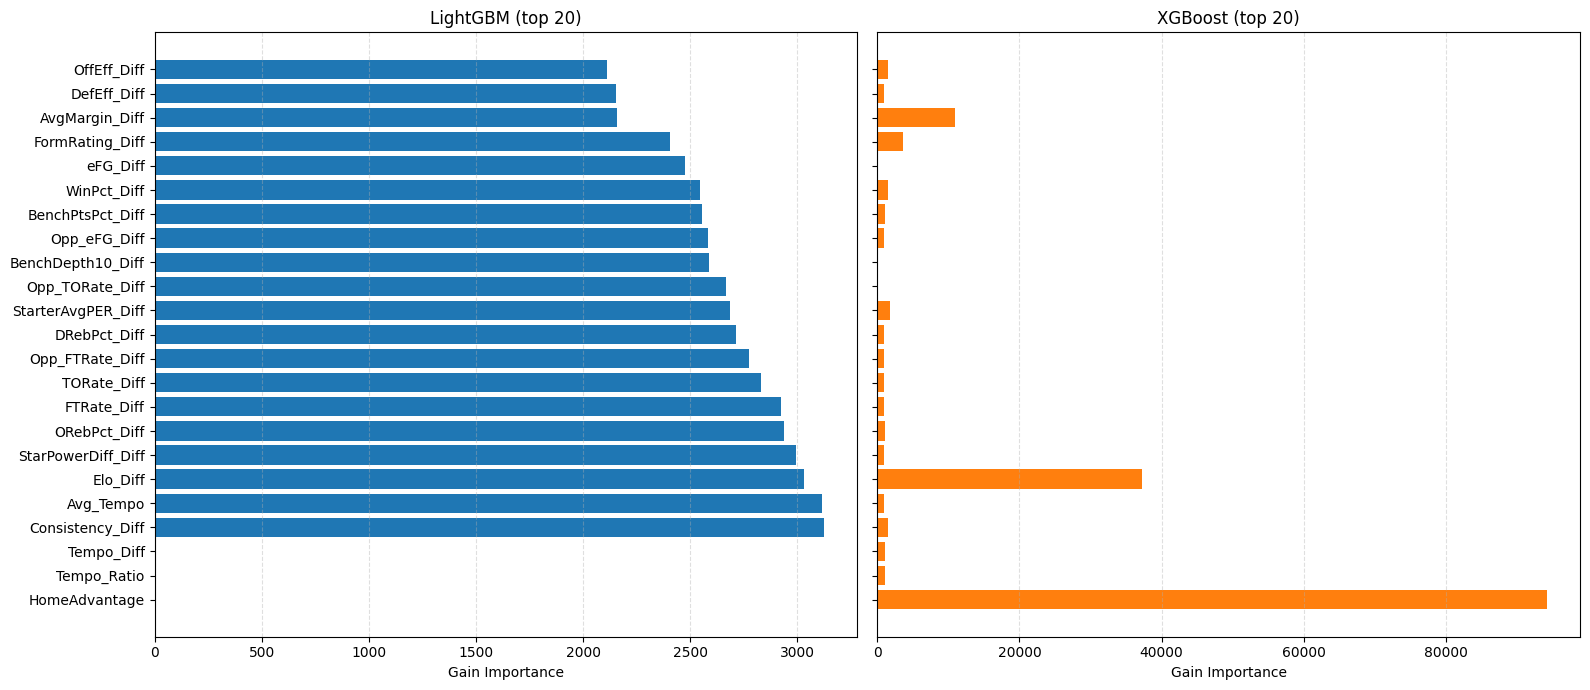

In [27]:
import matplotlib.pyplot as plt

def plot_gbm_feature_importances(lgb_model, xgb_model, feature_names, top_n=20, importance_type="gain"):
    """Plot top-N feature importances for LightGBM and XGBoost side by side."""
    feature_names = list(feature_names)
    top_n = min(top_n, len(feature_names))

    # LightGBM importance (split gain by default)
    lgb_importance = pd.Series(lgb_model.feature_importances_, index=feature_names)
    lgb_top = lgb_importance.sort_values(ascending=False).head(top_n)[::-1]

    # XGBoost importance (map booster feature names back to DataFrame columns)
    booster = xgb_model.get_booster()
    raw_importance = booster.get_score(importance_type=importance_type)
    index_map = {f"f{i}": name for i, name in enumerate(feature_names)}
    mapped_importance = {index_map.get(k, k): v for k, v in raw_importance.items()}
    xgb_importance = pd.Series(mapped_importance).reindex(feature_names).fillna(0.0)
    xgb_top = xgb_importance.sort_values(ascending=False).head(top_n)[::-1]

    fig_height = max(6, top_n * 0.35)
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_height), sharey=True)
    palettes = ['#1f77b4', '#ff7f0e']
    titles = [f"LightGBM (top {len(lgb_top)})", f"XGBoost (top {len(xgb_top)})"]

    for ax, data, color, title in zip(axes, [lgb_top, xgb_top], palettes, titles):
        ax.barh(data.index, data.values, color=color)
        ax.set_title(title)
        ax.set_xlabel('Gain Importance')
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    axes[0].invert_yaxis()  # Highest importance at the top across both plots
    plt.tight_layout()
    plt.show()

plot_gbm_feature_importances(
    lgb_model=lgb_model,
    xgb_model=xgb_model,
    feature_names=gbm_features,
    top_n=20
)

# Make Predictions

In [28]:
historical_spread_df = None
if os.path.exists("data/historical_spread_data.csv"):
    historical_spread_df = pd.read_csv("data/historical_spread_data.csv")

def _get_latest_team_stats(season, team_id):
    team_games = running_stats_df[
        (running_stats_df['Season'] == season) &
        ((running_stats_df['WTeamID'] == team_id) | (running_stats_df['LTeamID'] == team_id))
    ].sort_values('DayNum')

    if team_games.empty:
        raise ValueError(f"No games found for team {team_id} in season {season}")

    last_game = team_games.iloc[-1]
    if last_game['WTeamID'] == team_id:
        prefix = 'W_'
    else:
        prefix = 'L_'

    stat_names = [
        c[2:] for c in running_stats_df.columns
        if c.startswith('W_') and c not in [
            'WTeamID', 'WScore', 'WLoc', 'WGameNum'
        ]
    ]
    return {stat: last_game[f'{prefix}{stat}'] for stat in stat_names}


def _lookup_historical_spread(betting_line):
    if betting_line is None or historical_spread_df is None or historical_spread_df.empty:
        return None
    try:
        spread_mag = abs(float(betting_line))
    except (TypeError, ValueError):
        return None
    diffs = (historical_spread_df['Spread'] - spread_mag).abs()
    if diffs.isna().all():
        return None
    return historical_spread_df.loc[diffs.idxmin()]

model = trained_model
def predict_matchup(team1_id, team2_id, season=None, betting_line=None):
    if season is None:
        season = running_stats_df['Season'].max()
    stats1 = _get_latest_team_stats(season, team1_id)
    stats2 = _get_latest_team_stats(season, team2_id)
    team_lookup = mens_teams.set_index('TeamID')['TeamName']
    team1_name = team_lookup.get(team1_id, f'Team {team1_id}')
    team2_name = team_lookup.get(team2_id, f'Team {team2_id}')
    feat = {}
    for stat in stats1.keys():
        feat[f'{stat}_Diff'] = stats1[stat] - stats2[stat]
    feat['HomeAdvantage'] = 1  # team1 home
    feat['Avg_Tempo'] = (stats1['Tempo'] + stats2['Tempo']) / 2
    feat['Tempo_Ratio'] = stats1['Tempo'] / (stats2['Tempo'] + 1e-6)
    feat['Elo_Diff'] = stats1.get('Elo', np.nan) - stats2.get('Elo', np.nan)
    wide_vec = np.array([[feat.get(f, 0.0) for f in wide_features]])
    deep_vec = np.array([[feat.get(f, 0.0) for f in deep_features]])
    wide_scaled = wide_scaler.transform(wide_vec)
    deep_scaled = deep_scaler.transform(deep_vec)
    with torch.no_grad():
        pred_margin = model(
            torch.FloatTensor(wide_scaled).to(device),
            torch.FloatTensor(deep_scaled).to(device),
        ).cpu().numpy().flatten()[0]
    win_prob = stats.norm.cdf(pred_margin / 11.0)
    result = {
        'predicted_margin': pred_margin,
        'team1_win_probability': win_prob,
        'team2_win_probability': 1 - win_prob,
        'favorite_team_name': None,
        'favorite_predicted_to_cover': None,
        'favorite_cover_margin': None,
        'historical_spread_used': None,
        'historical_total_games': 0,
        'historical_home_cover_pct': None,
        'historical_away_cover_pct': None,
    }
    if betting_line is not None:
        historical_row = _lookup_historical_spread(betting_line)
        if historical_row is not None:
            result['historical_spread_used'] = float(historical_row['Spread'])
            result['historical_total_games'] = int(historical_row['Total_Games'])
            result['historical_home_cover_pct'] = float(historical_row['Home_Cover_Pct'])
            result['historical_away_cover_pct'] = float(historical_row['Away_Cover_Pct'])
        else:
            result['historical_spread_used'] = betting_line
        favorite_is_team1 = betting_line < 0
        result['favorite_team_name'] = team1_name if favorite_is_team1 else team2_name
        if favorite_is_team1:
            cover_margin = pred_margin + betting_line
        else:
            cover_margin = (-pred_margin) - betting_line
        result['favorite_cover_margin'] = cover_margin
        result['favorite_predicted_to_cover'] = cover_margin > 0
    return result

In [29]:
from numbers import Number

def build_detailed_matchup(team1_id, team2_id, season=None, betting_line=None):
    """Return a feature-rich comparison table plus engineered metrics for two teams."""
    if season is None:
        season = running_stats_df['Season'].max()

    stats1 = _get_latest_team_stats(season, team1_id)
    stats2 = _get_latest_team_stats(season, team2_id)

    team_lookup = mens_teams.set_index('TeamID')['TeamName']
    team1_name = team_lookup.get(team1_id, f'Team {team1_id}')
    team2_name = team_lookup.get(team2_id, f'Team {team2_id}')

    prediction = predict_matchup(team1_id, team2_id, season, betting_line=betting_line)

    comparison_rows = []
    for stat in sorted(stats1.keys()):
        val1 = stats1.get(stat, np.nan)
        val2 = stats2.get(stat, np.nan)
        diff = val1 - val2 if isinstance(val1, Number) and isinstance(val2, Number) else np.nan
        comparison_rows.append({
            'Metric': stat,
            team1_name: val1,
            team2_name: val2,
            'Diff (team1 - team2)': diff
        })

    comparison_df = pd.DataFrame(comparison_rows).set_index('Metric')

    def _safe_diff(a, b):
        return a - b if isinstance(a, Number) and isinstance(b, Number) else np.nan

    net_rating_team1 = stats1['OffEff'] - stats1['DefEff']
    net_rating_team2 = stats2['OffEff'] - stats2['DefEff']

    starter_avg_per_1 = stats1.get('StarterAvgPER', np.nan)
    starter_avg_per_2 = stats2.get('StarterAvgPER', np.nan)
    star_power_1 = stats1.get('StarPowerDiff', np.nan)
    star_power_2 = stats2.get('StarPowerDiff', np.nan)
    bench_pts_pct_1 = stats1.get('BenchPtsPct', np.nan)
    bench_pts_pct_2 = stats2.get('BenchPtsPct', np.nan)
    bench_depth_1 = stats1.get('BenchDepth10', np.nan)
    bench_depth_2 = stats2.get('BenchDepth10', np.nan)

    market_spread = prediction.get('historical_spread_used')
    model_edge = prediction['predicted_margin'] - market_spread if market_spread is not None else np.nan
    cover_margin = prediction.get('favorite_cover_margin') if market_spread is not None else np.nan

    advanced_features = {
        'HomeAdvantage': 1,
        'Avg_OffEff': np.mean([stats1['OffEff'], stats2['OffEff']]),
        'Avg_DefEff': np.mean([stats1['DefEff'], stats2['DefEff']]),
        'Avg_Tempo': np.mean([stats1['Tempo'], stats2['Tempo']]),
        'NetRating_Team1': net_rating_team1,
        'NetRating_Team2': net_rating_team2,
        'NetRating_Diff': net_rating_team1 - net_rating_team2,
        'Tempo_Ratio': stats1['Tempo'] / (stats2['Tempo'] + 1e-6),
        'OffEff_Diff': stats1['OffEff'] - stats2['OffEff'],
        'DefEff_Diff': stats1['DefEff'] - stats2['DefEff'],
        'Elo_Diff': stats1.get('Elo', np.nan) - stats2.get('Elo', np.nan),
        'StarterAvgPER_Team1': starter_avg_per_1,
        'StarterAvgPER_Team2': starter_avg_per_2,
        'StarterAvgPER_Diff': _safe_diff(starter_avg_per_1, starter_avg_per_2),
        'StarPowerDiff_Team1': star_power_1,
        'StarPowerDiff_Team2': star_power_2,
        'StarPowerDiff_Diff': _safe_diff(star_power_1, star_power_2),
        'BenchPtsPct_Team1': bench_pts_pct_1,
        'BenchPtsPct_Team2': bench_pts_pct_2,
        'BenchPtsPct_Diff': _safe_diff(bench_pts_pct_1, bench_pts_pct_2),
        'BenchDepth10_Team1': bench_depth_1,
        'BenchDepth10_Team2': bench_depth_2,
        'BenchDepth10_Diff': _safe_diff(bench_depth_1, bench_depth_2),
        'PredictedMargin': prediction['predicted_margin'],
        'WinProbability': prediction['team1_win_probability'],
        'MarketSpread': market_spread,
        'ModelEdge': model_edge,
        'CoverMargin': cover_margin,
    }

    summary = {
        'season': season,
        'team1_id': team1_id,
        'team2_id': team2_id,
        'team1_name': team1_name,
        'team2_name': team2_name,
        **advanced_features
    }

    return comparison_df.sort_index(), summary

In [30]:
import re
import requests
from datetime import datetime, timedelta
from difflib import get_close_matches
from dotenv import load_dotenv

load_dotenv()

ODDS_API_KEY = os.getenv("ODDS_API_KEY")
print(ODDS_API_KEY)

TEAM_ALIASES = {
    "Wright St Raiders": "Wright State Raiders",
    "SIU-Edwardsville Cougars": "SIU Edwardsville Cougars",
    "UMKC Kangaroos": "Kansas City Roos",
    "Loyola (Chi) Ramblers": "Loyola Chicago Ramblers",
    "Youngstown St Penguins": "Youngstown State Penguins",
    "Florida St Seminoles": "Florida State Seminoles",
    "Arkansas-Little Rock Trojans": "Little Rock Trojans",
    "Colorado St Rams": "Colorado State Rams",
    "GW Revolutionaries": "George Washington Revolutionaries",
    "Central Connecticut St Blue Devils": "Central Connecticut Blue Devils",
    "Chicago St Cougars": "Chicago State Cougars",
    "LIU Sharks": "Long Island University Sharks",
    "St. Bonaventure Bonnies": "St. Bonaventure Bonnies",
}

def _normalize_team_name(name):
    if not isinstance(name, str):
        return ""
    return re.sub(r"[^a-z0-9]+", " ", name.lower()).strip()

def _build_team_lookup(mens_teams_df):
    exact_lookup = dict(zip(mens_teams_df["TeamName"].astype(str), mens_teams_df["TeamID"].astype(str)))
    norm_lookup = {}
    for team_name, team_id in exact_lookup.items():
        norm_lookup.setdefault(_normalize_team_name(team_name), team_id)
    return exact_lookup, norm_lookup

def _resolve_team_id(team_name, exact_lookup, norm_lookup):
    candidate = TEAM_ALIASES.get(team_name, team_name)
    if candidate in exact_lookup:
        return exact_lookup[candidate]

    candidate_norm = _normalize_team_name(candidate)
    if candidate_norm in norm_lookup:
        return norm_lookup[candidate_norm]

    possible = get_close_matches(candidate_norm, list(norm_lookup.keys()), n=1, cutoff=0.92)
    if possible:
        return norm_lookup[possible[0]]

    return None

def get_est_day_in_utc():
    today = datetime.now().date()
    est_start_as_utc = datetime.combine(today, datetime.min.time()) + timedelta(hours=5)
    est_end_as_utc = est_start_as_utc + timedelta(hours=23, minutes=59)
    commence_from = est_start_as_utc.strftime("%Y-%m-%dT%H:%M:%SZ")
    commence_to = est_end_as_utc.strftime("%Y-%m-%dT%H:%M:%SZ")
    return commence_from, commence_to

def get_todays_odds():
    base_url = "https://api.the-odds-api.com/v4/sports/basketball_ncaab/odds"
    commence_from, commence_to = get_est_day_in_utc()

    params = {
        "apiKey": ODDS_API_KEY,
        "regions": "us",
        "markets": "spreads",
        "dateFormat": "iso",
        "oddsFormat": "decimal",
        "bookmakers": "draftkings",
        "commenceTimeFrom": commence_from,
        "commenceTimeTo": commence_to,
        "includeLinks": "false",
        "includeSids": "false",
        "includeBetLimits": "false",
        "includeRotationNumbers": "false",
    }

    response = requests.get(base_url, params=params, timeout=30)
    if response.status_code != 200:
        print(f"Error: {response.status_code}")
        print(response.text)
        return None

    data = response.json()
    print(f"Successfully retrieved {len(data)} games.")
    return data

def _extract_home_spread(game):
    home_team = game.get("home_team")
    away_team = game.get("away_team")
    bookmakers = game.get("bookmakers", [])

    bookmaker = next((b for b in bookmakers if b.get("key") == "draftkings"), None)
    if bookmaker is None:
        return None

    market = next((m for m in bookmaker.get("markets", []) if m.get("key") == "spreads"), None)
    if market is None:
        return None

    outcomes = market.get("outcomes", [])
    if not outcomes:
        return None

    outcome_map = {}
    for outcome in outcomes:
        name = TEAM_ALIASES.get(outcome.get("name", ""), outcome.get("name", ""))
        outcome_map[_normalize_team_name(name)] = outcome.get("point")

    home_key = _normalize_team_name(TEAM_ALIASES.get(home_team, home_team))
    away_key = _normalize_team_name(TEAM_ALIASES.get(away_team, away_team))

    home_spread = outcome_map.get(home_key)
    away_spread = outcome_map.get(away_key)

    if home_spread is None and away_spread is not None:
        return -float(away_spread)

    return home_spread

def build_todays_matchups(mens_teams_df):
    odds_data = get_todays_odds()
    if not odds_data:
        print("No odds data available for today.")
        return []

    exact_lookup, norm_lookup = _build_team_lookup(mens_teams_df)
    matchups = []

    for game in odds_data:
        home_team = game.get("home_team")
        away_team = game.get("away_team")

        home_teamid = _resolve_team_id(home_team, exact_lookup, norm_lookup)
        away_teamid = _resolve_team_id(away_team, exact_lookup, norm_lookup)
        if home_teamid is None or away_teamid is None:
            print(f"Skipping game (team mapping failed): {away_team} @ {home_team}")
            continue

        home_spread = _extract_home_spread(game)
        if home_spread is None:
            print(f"Skipping game (no spread found): {away_team} @ {home_team}")
            continue

        matchups.append((home_teamid, away_teamid, float(home_spread)))

    return matchups

matchups = build_todays_matchups(mens_teams)
print(f"Today's matchups (TeamID_A, TeamID_B, Spread): {len(matchups)}")
for m in matchups:
    print(m)

532d6a0904a3184f84861fab429128c4
Successfully retrieved 7 games.
Skipping game (team mapping failed): Arkansas-Little Rock Trojans @ Lindenwood Lions
Today's matchups (TeamID_A, TeamID_B, Spread): 6
('s:40~l:41~t:290', 's:40~l:41~t:295', -5.5)
('s:40~l:41~t:221', 's:40~l:41~t:52', 5.5)
('s:40~l:41~t:87', 's:40~l:41~t:24', 8.5)
('s:40~l:41~t:248', 's:40~l:41~t:239', -1.5)
('s:40~l:41~t:167', 's:40~l:41~t:36', 1.5)
('s:40~l:41~t:264', 's:40~l:41~t:30', -3.5)


In [ ]:
import numpy as np
import pandas as pd
import os
import markdown
from llm import get_response


output_html_path = "matchup_report.html"

# Modernized CSS with better hierarchy and colors
html_rows = [
    "<!doctype html>",
    "<html lang='en'>",
    "<head>",
    "  <meta charset='utf-8' />",
    "  <meta name='viewport' content='width=device-width, initial-scale=1' />",
    "  <title>CBB Matchup Intelligence</title>",
    "  <style>",
    "    :root { --bg: #0b0f13; --panel: #161b22; --border: #30363d; --text: #c9d1d9; --muted: #8b949e; --accent: #58a6ff; --win: #238636; --loss: #da3633; }",
    "    body { margin: 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Helvetica, Arial, sans-serif; background: var(--bg); color: var(--text); line-height: 1.5; }",
    "    header { padding: 40px 20px; background: linear-gradient(180deg, #161b22 0%, var(--bg) 100%); border-bottom: 1px solid var(--border); text-align: center; }",
    "    h1 { margin: 0; font-size: 32px; font-weight: 600; color: #fff; }",
    "    .sub { color: var(--muted); font-size: 16px; margin-top: 8px; }",
    "    main { padding: 20px; max-width: 1000px; margin: 0 auto; }",
    "    .matchup { background: var(--panel); border: 1px solid var(--border); border-radius: 12px; margin-bottom: 20px; overflow: hidden; transition: transform 0.2s; }",
    "    .matchup:hover { border-color: #8b949e; }",
    "    summary { cursor: pointer; padding: 20px; font-size: 18px; font-weight: 600; display: flex; justify-content: space-between; align-items: center; list-style: none; }",
    "    summary::-webkit-details-marker { display: none; }",
    "    .summary-content { display: flex; justify-content: space-between; width: 100%; align-items: center; }",
    "    .line-badge { background: #21262d; padding: 4px 12px; border-radius: 20px; font-size: 14px; border: 1px solid var(--border); }",
    "    .details-container { padding: 0 20px 20px; border-top: 1px solid var(--border); background: #0d1117; }",
    "    .meta-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; padding: 20px 0; border-bottom: 1px solid var(--border); }",
    "    .section-title { font-size: 12px; text-transform: uppercase; letter-spacing: 1px; color: var(--muted); margin-bottom: 10px; font-weight: bold; }",
    "    .pred-card { background: #161b22; padding: 15px; border-radius: 8px; border-left: 4px solid var(--accent); }",
    "    .cover-status.covers { color: #3fb950; font-weight: bold; }",
    "    .cover-status.no-cover { color: #f85149; font-weight: bold; }",
    "    .player-edges { list-style: none; padding: 0; margin: 0; font-size: 14px; }",
    "    .player-edges li { margin-bottom: 4px; display: flex; justify-content: space-between; }",
    "    .analysis-section { margin-top: 20px; padding: 15px; background: #161b22; border-radius: 8px; border: 1px solid var(--border); }",
    "    .analysis-section p { margin: 0; font-size: 14px; line-height: 1.6; }",
    "    .table-wrap { margin-top: 20px; overflow-x: auto; border-radius: 8px; border: 1px solid var(--border); }",
    "    table { border-collapse: collapse; width: 100%; background: #161b22; }",
    "    th, td { padding: 12px; text-align: right; font-size: 13px; border-bottom: 1px solid var(--border); }",
    "    th { background: #21262d; color: var(--muted); font-weight: 500; }",
    "    td:first-child, th:first-child { text-align: left; color: var(--muted); }",
    "    tr:hover td { background: #1c2128; }",
    "    .positive { color: #3fb950; } .negative { color: #f85149; }",
    "  </style>",
    "</head>",
    "<body>",
    "<header>",
    "  <h1>Matchup Intelligence Report</h1>",
    "  <div class='sub'>Deep Learning Predictions vs. Market Lines</div>",
    "</header>",
    "<main>"
]

season_for_report = running_stats_df['Season'].max()

for team1_id, team2_id, line in matchups:
    comparison_df, summary = build_detailed_matchup(
        team1_id, team2_id, season=season_for_report, betting_line=line
    )
    result = predict_matchup(team1_id, team2_id, season=season_for_report, betting_line=line)
    
    # Logic for Cover Styling
    is_cover = result['favorite_predicted_to_cover']
    cover_class = "covers" if is_cover else "no-cover"
    covers_text = "COVERS" if is_cover else "DOES NOT COVER"
    
    # Build Header Content
    spread_val = f"({line:+.1f})" if line is not None else ""
    title_html = f"<div class='summary-content'><span>{summary['team2_name']} @ {summary['team1_name']}</span> <span class='line-badge'>Spread: {spread_val}</span></div>"

    html_rows.append("<details class='matchup'>")
    html_rows.append(f"  <summary>{title_html}</summary>")
    html_rows.append("  <div class='details-container'>")
    
    # Grid for Meta and Player Edges
    html_rows.append("    <div class='meta-grid'>")
    
    # Column 1: Model Prediction
    html_rows.append("      <div>")
    html_rows.append("        <div class='section-title'>Model Forecast</div>")
    html_rows.append("        <div class='pred-card'>")
    win_team = summary['team1_name'] if result['predicted_margin'] > 0 else summary['team2_name']
    html_rows.append(f"        <div style='font-size: 16px; color:#fff;'><b>{win_team}</b> by {abs(result['predicted_margin']):.1f} pts</div>")
    html_rows.append(f"        <div style='font-size: 13px; margin-top:5px;'>Win Prob: {result['team1_win_probability']:.1%} (H) / {result['team2_win_probability']:.1%} (A)</div>")
    
    if line is not None:
        html_rows.append(f"        <div class='cover-status {cover_class}' style='margin-top:10px;'>{covers_text} by {abs(result['favorite_cover_margin']):.1f}</div>")
    html_rows.append("        </div>")
    html_rows.append("      </div>")

    # Column 2: Rotation Edges
    html_rows.append("      <div>")
    html_rows.append("        <div class='section-title'>Rotation Edges (H-A)</div>")
    html_rows.append("        <ul class='player-edges'>")
    
    metrics = [
        ('Starter PER', summary.get('StarterAvgPER_Diff'), "+.2f"),
        ('Star Power', summary.get('StarPowerDiff_Diff'), "+.2f"),
        ('Bench Depth', summary.get('BenchDepth10_Diff'), "+.1f"),
        ('Bench Pts %', summary.get('BenchPtsPct_Diff', 0)*100, "+.1f")
    ]
    
    for label, val, fmt in metrics:
        if pd.notna(val):
            color_class = "positive" if val > 0 else "negative"
            html_rows.append(f"<li><span>{label}:</span> <span class='{color_class}'>{val:{fmt}}</span></li>")
    
    html_rows.append("        </ul>")
    html_rows.append("      </div>")
    html_rows.append("    </div>") # End Grid

    # Generate AI analysis
    stats_text = f"""
Matchup: {summary['team2_name']} @ {summary['team1_name']}
Home Team: {summary['team1_name']}
Away Team: {summary['team2_name']}
Predicted Winner: {win_team} by {abs(result['predicted_margin']):.1f} pts
Win Probabilities: Home {result['team1_win_probability']:.1%} / Away {result['team2_win_probability']:.1%}
Detailed Stats:
{comparison_df.to_string()}
"""
    try:
        print(f"Generating AI analysis for matchup between {summary['team1_name']} and {summary['team2_name']}...")
        analysis = get_response(summary)
    except Exception as e:
        analysis = f"Error generating analysis: {e}"

    html_rows.append("    <div class='analysis-section'>")
    html_rows.append("      <div class='section-title'>AI Analysis</div>")
    html_rows.append(f"      <p>{markdown.markdown(analysis)}</p>")
    html_rows.append("    </div>")

    # Table section
    html_rows.append("    <div class='table-wrap'>")
    # Styling the dataframe values before converting to HTML
    formatted_df = comparison_df.reset_index()
    table_html = formatted_df.to_html(index=False, classes='dataframe', border=0, justify='right')
    html_rows.append(table_html)
    html_rows.append("    </div>")
    
    html_rows.append("  </div>")
    html_rows.append("</details>")

html_rows.append("</main></body></html>")
with open(output_html_path, "w", encoding="utf-8") as f:
    f.write("\n".join(html_rows))
print(f"Wrote HTML report to: {output_html_path}")

Generating AI analysis for matchup between Georgia Southern Eagles and Old Dominion Monarchs...
Generating AI analysis for matchup between Pittsburgh Panthers and Florida State Seminoles...
Generating AI analysis for matchup between Notre Dame Fighting Irish and Stanford Cardinal...
Generating AI analysis for matchup between Houston Cougars and Baylor Bears...
Generating AI analysis for matchup between New Mexico Lobos and Colorado State Rams...
Generating AI analysis for matchup between Washington Huskies and USC Trojans...
Wrote HTML report to: matchup_report.html


## Save Model

In [32]:
# Save model and scalers
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'wide_scaler': wide_scaler,
    'deep_scaler': deep_scaler,
    'wide_features': wide_features,
    'deep_features': deep_features,
}, 'regular_season_model_enhanced.pth')

print("Model saved to regular_season_model_enhanced.pth")

Model saved to regular_season_model_enhanced.pth


## Summary

This model predicts regular season game outcomes using:

**No Data Leakage**: Running statistics calculated progressively through the season

**Excludes Games with Zero Stats**: Avoids cold-start issues with zero-initialized stats

**Advanced Metrics**:
- Efficiency and pace (OffEff/DefEff, Tempo)
- Consistency: Standard deviation of recent margins (volatility measure)
- Form Rating: Exponentially weighted recent performance (10-game half-life)

**Elo Rating**: Updated after each game to capture team strength

**Home Court Advantage**: Explicit feature for home/away/neutral games

**Wide & Deep Architecture**: Same proven architecture from March Madness model